In [1]:
# to ignore the warning messages with KMeans
import os
import sys
from pathlib import Path

# sys.path.append('..')
print(os.path.abspath(""))


# Get my_package directory path from Notebook
parent_dir = str(Path().resolve().parents[0])

# Add to sys.path
sys.path.insert(0, parent_dir)

print(parent_dir)


current_path = os.getcwd()
print(current_path)
sys.path.append(os.path.join(os.path.dirname(current_path), '..'))


import pandas as pd
import numpy as np
import scipy as sc
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import pickle
import pyxdf
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from libML.data_load_and_label_for_training import load_emg_data
from libML.data_loading_xdf import load_csv_file, load_xdf_file
from libML.preprocessing_new import notch_filter, passband_filter
from libML.snr import *
from libML.plots_figures import *
from libML.utils import *

%load_ext autoreload
%autoreload 2

from glob import glob


c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\notebooks
C:\Users\willi\Desktop\BMI-Software\Signal Processing & ML
c:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\notebooks


## EPFL custom setup - Kraken

In [22]:
subject = '008'
session = '001'

In [23]:
xdf_dir = f"C:/Users/willi/Desktop/BMI-Software/Signal Processing & ML/data/raw/sub-P{subject}/ses-S{session}/emg/"
xdf_file = f'sub-P{subject}_ses-S{session}_task-Default_run-001_emg_kraken.xdf'
data_xdf_path = os.path.join(xdf_dir, xdf_file)

streams, header = pyxdf.load_xdf(data_xdf_path)

In [24]:
channels = streams[1]['time_series']
timestamps = streams[1]['time_stamps']

In [25]:
data_df = pd.DataFrame(data=channels, columns=['Channel_1', 'Channel_2', 'Channel_3', 'Channel_4', 'Channel_5', 'Channel_6'])
data_df['Time'] = timestamps

In [38]:
time = data_df['Time']
channels = data_df.drop(columns='Time')

print(f"Time {time}")
print(f"Channels {channels}")

filtered1_channels = notch_filter(channels, single=True)
filtered2_channels = passband_filter(filtered1_channels, single=True)

data_df = pd.concat([time, filtered2_channels], axis=1)

Time 0         336015.978882
1         336015.980882
2         336015.982882
3         336015.984882
4         336015.986882
              ...      
441240    336898.473224
441241    336898.475224
441242    336898.477224
441243    336898.479224
441244    336898.481224
Name: Time, Length: 441245, dtype: float64
Channels         Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6
0          7981.0     7930.0     7778.0     7992.0     7968.0     5958.0
1          7983.0     7906.0     7931.0     7889.0     7973.0     5949.0
2          8010.0     7896.0     7943.0     7940.0     7934.0     5925.0
3          7979.0     7888.0     8155.0     7802.0     7918.0     5919.0
4          7921.0     7910.0     8192.0     7905.0     7914.0     5919.0
...           ...        ...        ...        ...        ...        ...
441240     8047.0     8104.0     8168.0     8096.0     8090.0     6065.0
441241     8077.0     8079.0     8183.0     8120.0     8088.0     6067.0
441242     8039.0     

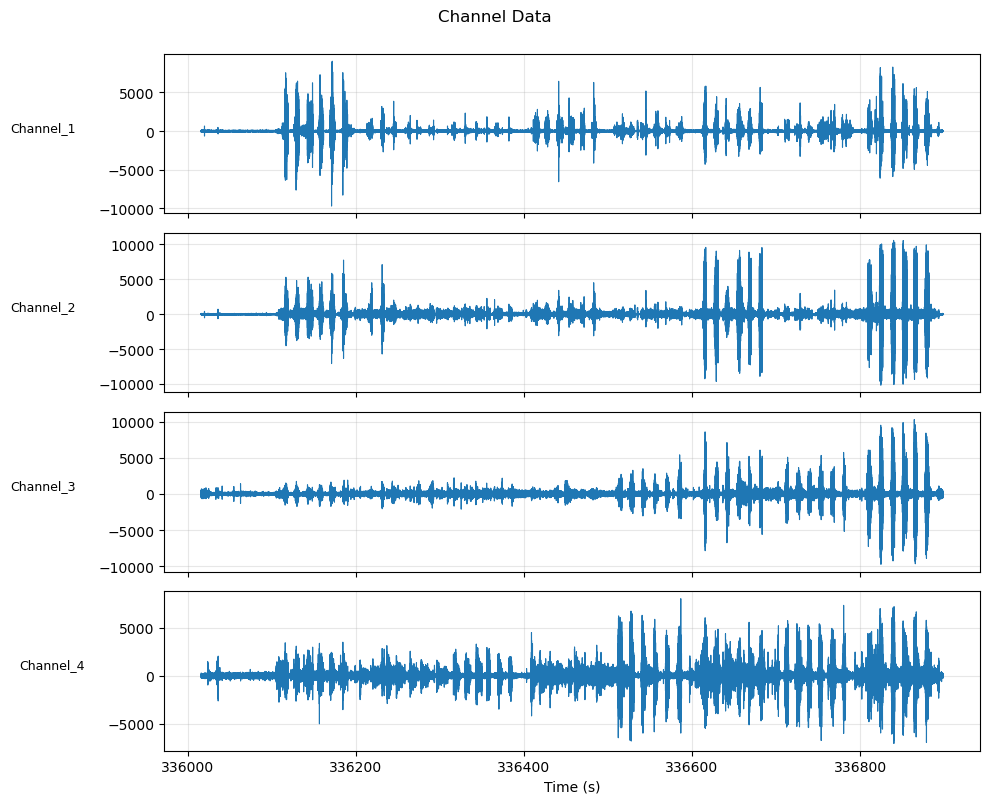

In [39]:
plot_stacked_channels(data_df.drop(columns=["Channel_5", "Channel_6"]))

In [ ]:
sig_t0=336120
sig_t1=336200
noi_t0=336020
noi_t1=336100

signal = data_df.loc[(data_df['Time'] >= sig_t0) & (data_df['Time'] < sig_t1)].copy().drop(columns=["Channel_5", "Channel_6"])
noise  = data_df.loc[(data_df['Time'] >= noi_t0) & (data_df['Time'] < noi_t1)].copy().drop(columns=["Channel_5", "Channel_6"])

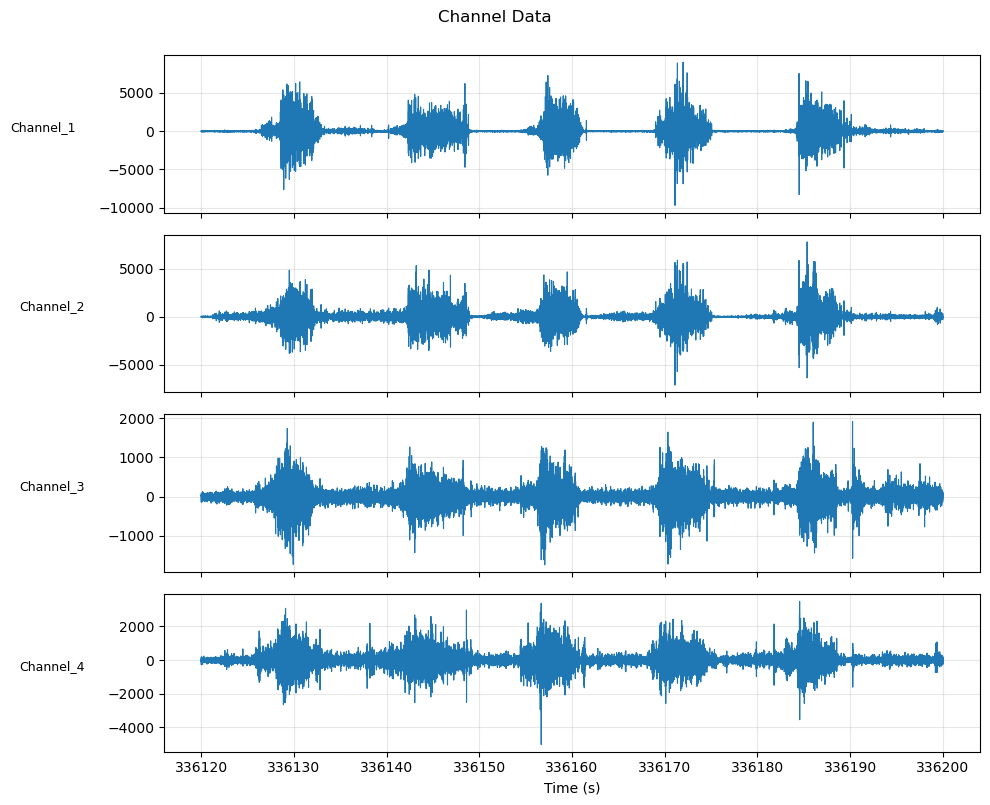

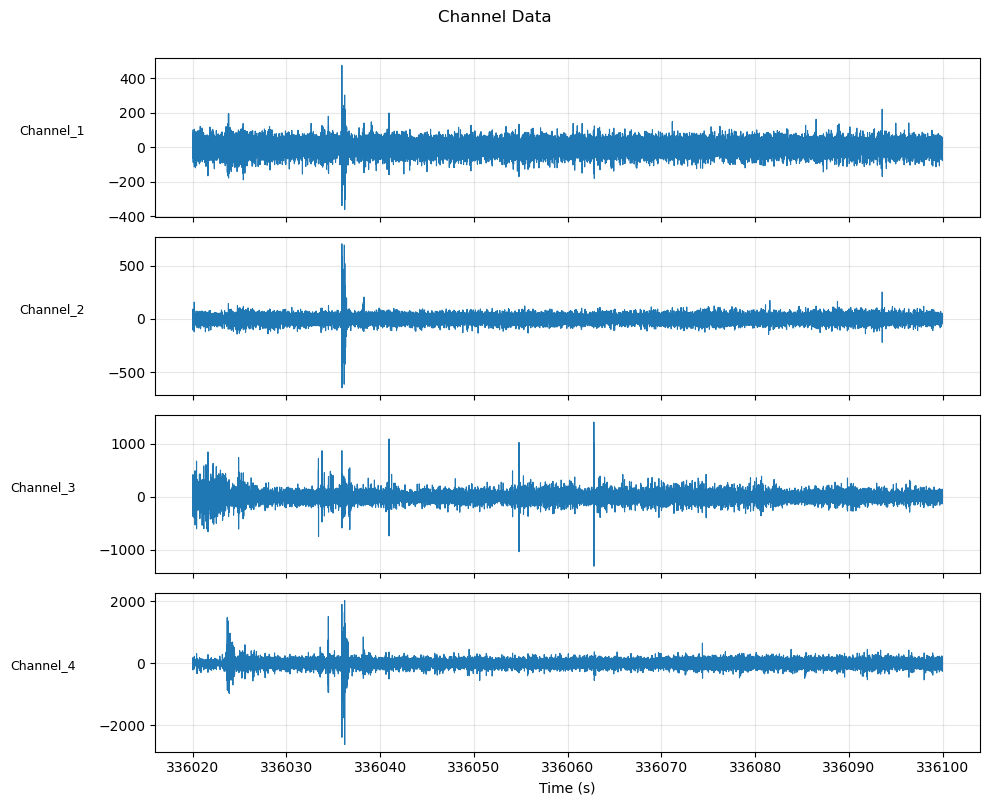

In [45]:
plot_stacked_channels(signal)
plot_stacked_channels(noise)

In [46]:
snr_list = []
for col_name, data in signal.items():
    if "Channel" in col_name:    
        s = signal[col_name].values
        n = noise[col_name].values

        snr = compute_snr(s, n)
        print(f"SNR for channel {col_name}: {round(snr, 2)}dB")
        snr_list.append(snr)

snr_mean = np.mean(snr_list)
print(f"Mean SNR: {round(snr_mean, 2)}dB")

SNR for channel Channel_1: 26.24dB
SNR for channel Channel_2: 23.93dB
SNR for channel Channel_3: 7.73dB
SNR for channel Channel_4: 10.21dB
Mean SNR: 17.03dB


In [49]:
raw_data_path = os.path.join(parent_dir, "data/raw")
emg_files = {}

for (root, dirs, files) in os.walk(raw_data_path):
    print(f"Root: {root}")
    print(f"Directories: {dirs}")
    print(f"Files: {files}")

    if len(files)!=0:
        if "sub-P" in root and "beh" not in root:
            emg_files_only = []
            for file in files:
                # if ".csv" in file or ".xdf" in file:
                if "kraken.xdf" in file:
                    emg_files_only.append(file)
            emg_files[root] = emg_files_only

Root: C:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\data/raw
Directories: ['sub-01', 'sub-P005', 'sub-P006', 'sub-P008', 'sub-P009']
Files: []
Root: C:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\data/raw\sub-01
Directories: ['emg']
Files: []
Root: C:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\data/raw\sub-01\emg
Directories: []
Files: ['sub-01_task-Cyl_acq-cometa_channels.tsv', 'sub-01_task-Cyl_acq-cometa_emg.csv', 'sub-01_task-Cyl_acq-cometa_emg.edf', 'sub-01_task-Cyl_acq-cometa_emg.json']
Root: C:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\data/raw\sub-P005
Directories: ['ses-S002', 'ses-S003', 'ses-S004', 'ses-S005', 'ses-S006', 'ses-S007', 'ses-S008', 'ses-S009']
Files: []
Root: C:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\data/raw\sub-P005\ses-S002
Directories: ['emg']
Files: []
Root: C:\Users\willi\Desktop\BMI-Software\Signal Processing & ML\data/raw\sub-P005\ses-S002\emg
Directories: []
Files: ['sub-P005_ses-S002_

In [50]:
emg_files

{'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S002\\emg': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S003\\emg': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S004\\emg': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S005': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S006': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S007': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S008': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P005\\ses-S009': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Processing & ML\\data/raw\\sub-P006\\NMOD_Wireless_EMG_test': [],
 'C:\\Users\\willi\\Desktop\\BMI-Software\\Signal Pro

Time 0         336015.978882
1         336015.980882
2         336015.982882
3         336015.984882
4         336015.986882
              ...      
441240    336898.473224
441241    336898.475224
441242    336898.477224
441243    336898.479224
441244    336898.481224
Name: Time, Length: 441245, dtype: float64
Channels         Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6
0          7981.0     7930.0     7778.0     7992.0     7968.0     5958.0
1          7983.0     7906.0     7931.0     7889.0     7973.0     5949.0
2          8010.0     7896.0     7943.0     7940.0     7934.0     5925.0
3          7979.0     7888.0     8155.0     7802.0     7918.0     5919.0
4          7921.0     7910.0     8192.0     7905.0     7914.0     5919.0
...           ...        ...        ...        ...        ...        ...
441240     8047.0     8104.0     8168.0     8096.0     8090.0     6065.0
441241     8077.0     8079.0     8183.0     8120.0     8088.0     6067.0
441242     8039.0     

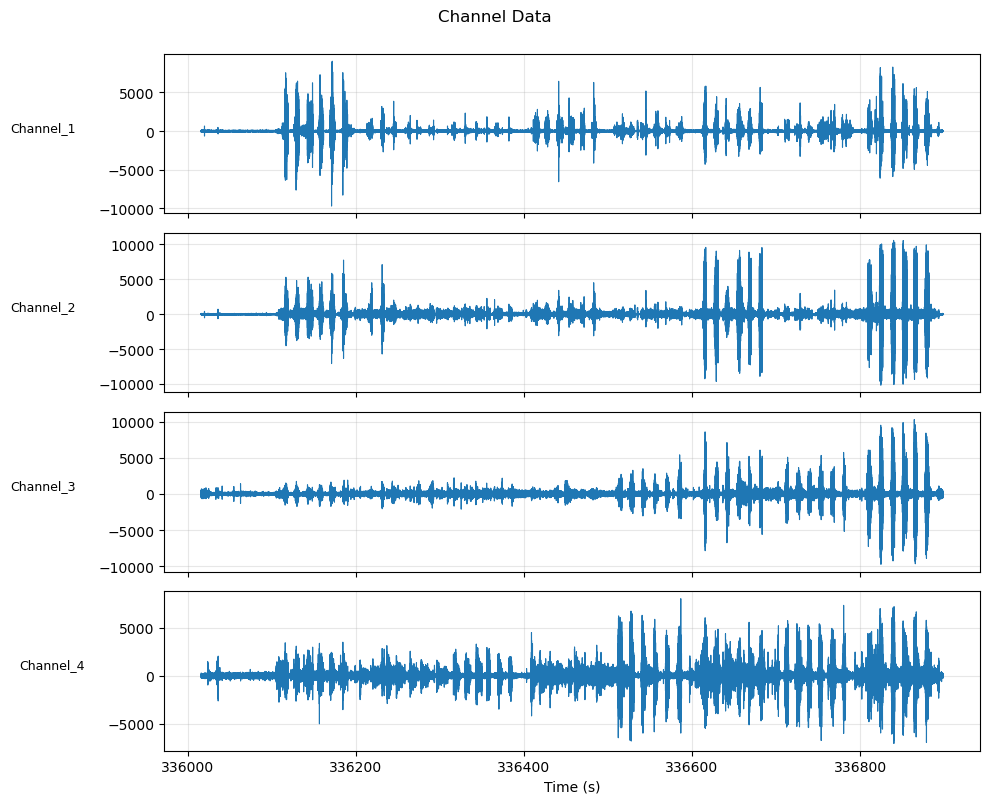

Time 0         337682.076887
1         337682.078887
2         337682.080887
3         337682.082887
4         337682.084887
              ...      
500743    338683.567416
500744    338683.569417
500745    338683.571417
500746    338683.573417
500747    338683.575417
Name: Time, Length: 500748, dtype: float64
Channels         Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6
0          8093.0     8227.0     7878.0     8089.0     8127.0     6079.0
1          7680.0     8068.0     7915.0     8025.0     8125.0     6070.0
2          8347.0     7803.0     7859.0     7928.0     8128.0     6119.0
3          8352.0     8180.0     8002.0     8109.0     8134.0     6131.0
4          8169.0     8182.0     8029.0     8170.0     8156.0     6139.0
...           ...        ...        ...        ...        ...        ...
500743     8069.0     8143.0     8237.0     8108.0     8107.0     6071.0
500744     8047.0     8157.0     8265.0     8114.0     8119.0     6087.0
500745     8055.0     

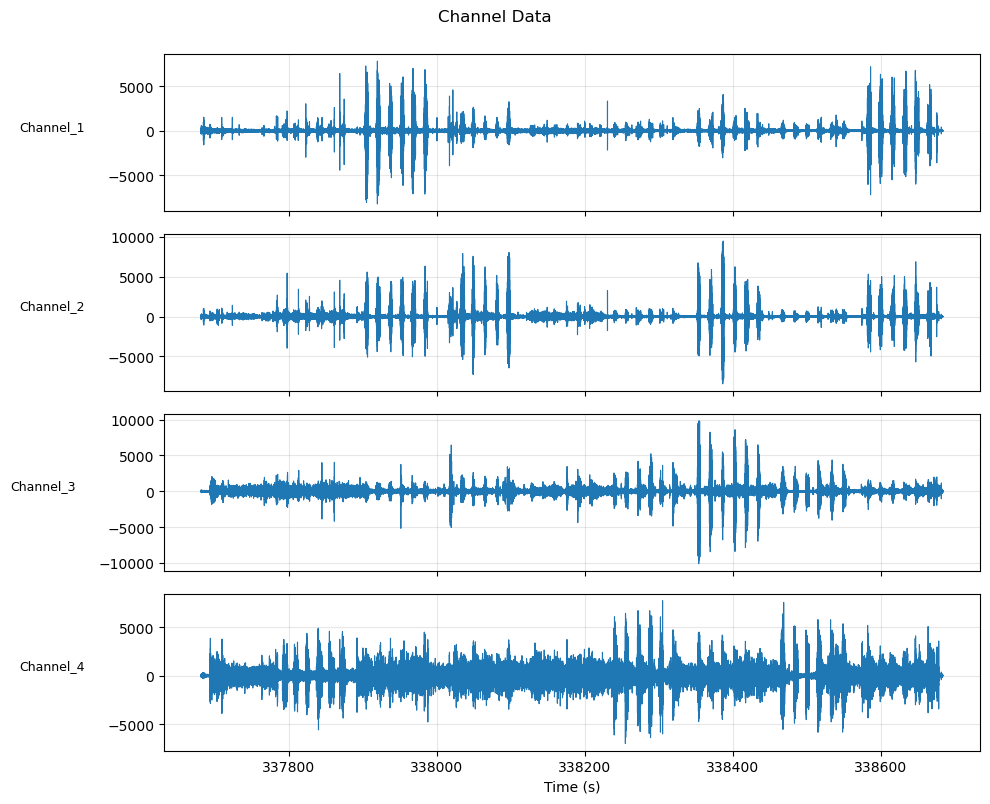

Time 0         338987.565272
1         338987.567272
2         338987.569272
3         338987.571272
4         338987.573272
              ...      
509743    340007.066795
509744    340007.068795
509745    340007.070795
509746    340007.072795
509747    340007.074795
Name: Time, Length: 509748, dtype: float64
Channels         Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6
0          7530.0     7994.0     8099.0     8002.0     8163.0     6138.0
1          7503.0     7904.0     8096.0     8115.0     8187.0     6122.0
2          7972.0     8130.0     8111.0     8167.0     8192.0     6076.0
3          8074.0     8070.0     8144.0     8244.0     8207.0     6079.0
4          8102.0     8090.0     8187.0     8407.0     8261.0     6143.0
...           ...        ...        ...        ...        ...        ...
509743     8195.0     8240.0     8331.0     8203.0     8159.0     6142.0
509744     8312.0     8573.0     8337.0     8230.0     8156.0     6139.0
509745     8183.0     

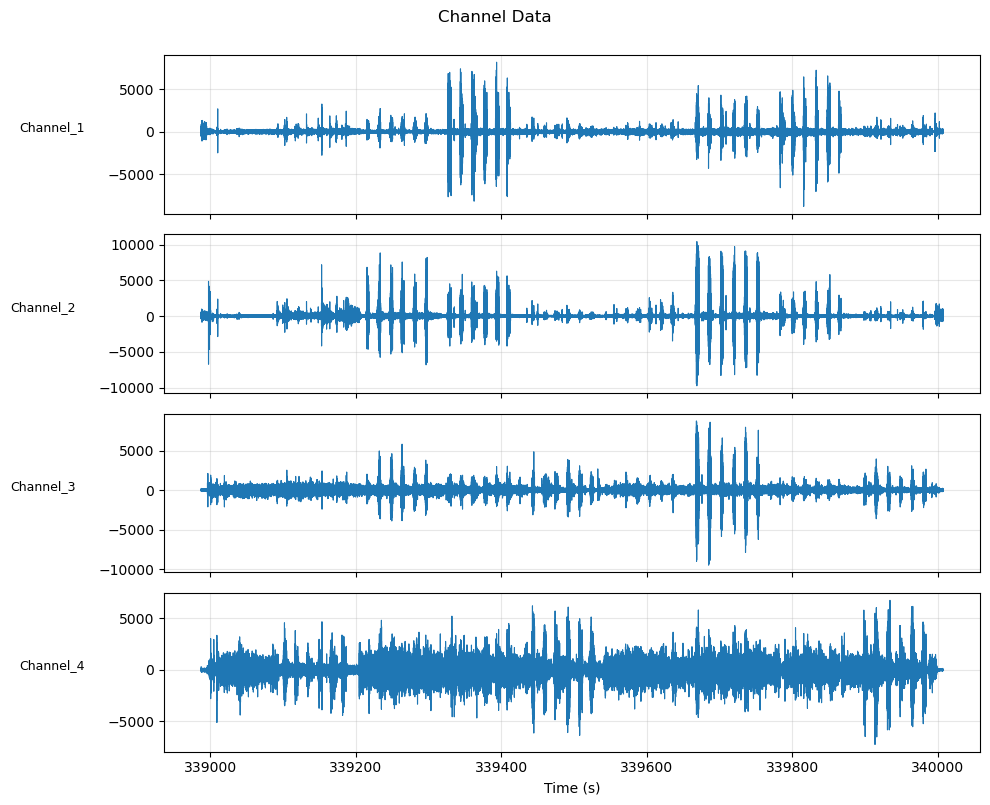

Time 0         342326.125231
1         342326.127231
2         342326.129231
3         342326.131231
4         342326.133231
              ...      
495242    343316.621452
495243    343316.623452
495244    343316.625452
495245    343316.627452
495246    343316.629452
Name: Time, Length: 495247, dtype: float64
Channels         Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6
0          7997.0     8103.0     8194.0     8188.0     8251.0     6089.0
1          8092.0     8015.0     8222.0     8250.0     8206.0     6081.0
2          8119.0     8168.0     8177.0     8188.0     8197.0     6077.0
3          8312.0     8334.0     8175.0     8197.0     8181.0     6117.0
4          8129.0     8098.0     8197.0     8273.0     8188.0     6117.0
...           ...        ...        ...        ...        ...        ...
495242     8098.0     8006.0     8214.0     8043.0     8174.0     6143.0
495243     8063.0     7943.0     8193.0     8043.0     8138.0     6129.0
495244     7979.0     

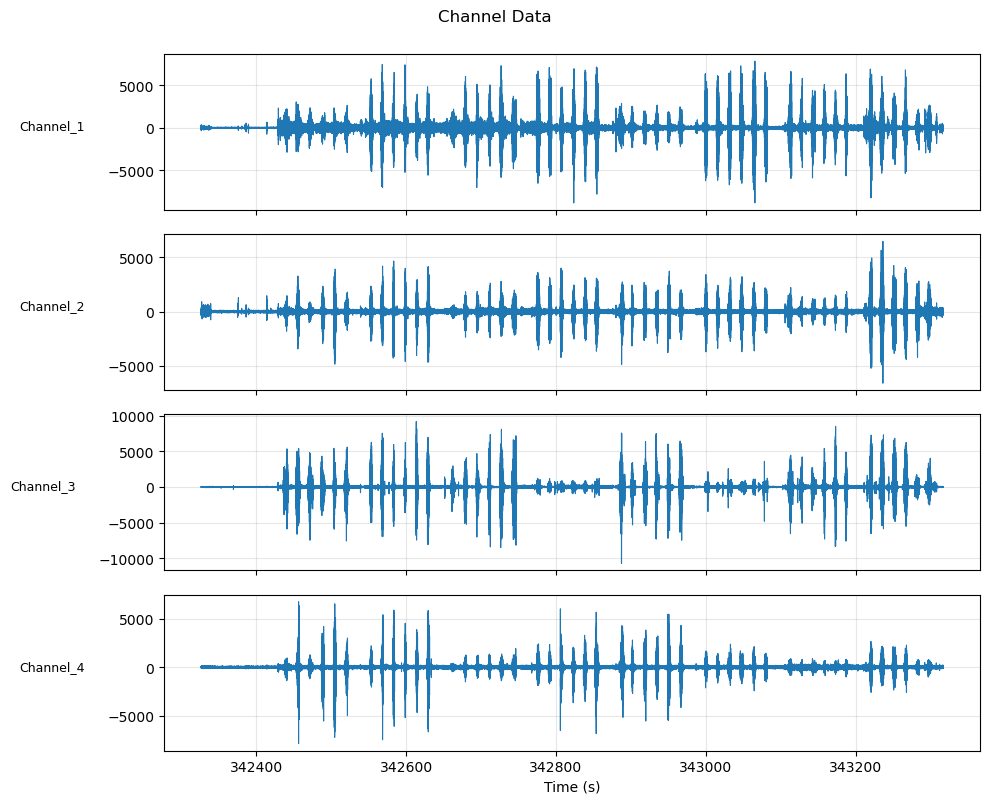

Time 0         343526.987625
1         343526.989625
2         343526.991625
3         343526.993625
4         343526.995625
              ...      
499996    344526.982488
499997    344526.984488
499998    344526.986488
499999    344526.988488
500000    344526.990488
Name: Time, Length: 500001, dtype: float64
Channels         Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6
0          8213.0     8189.0     8194.0     8154.0     8102.0     6071.0
1          8187.0     8151.0     8136.0     8197.0     8137.0     6113.0
2          8185.0     8205.0     8089.0     8205.0     8190.0     6147.0
3          8143.0     8235.0     8117.0     8225.0     8186.0     6134.0
4          8124.0     8113.0     8210.0     8192.0     8179.0     6112.0
...           ...        ...        ...        ...        ...        ...
499996     8104.0     8069.0     8026.0     8092.0     8103.0     6067.0
499997     8097.0     8123.0     8079.0     8137.0     8142.0     6119.0
499998     8159.0     

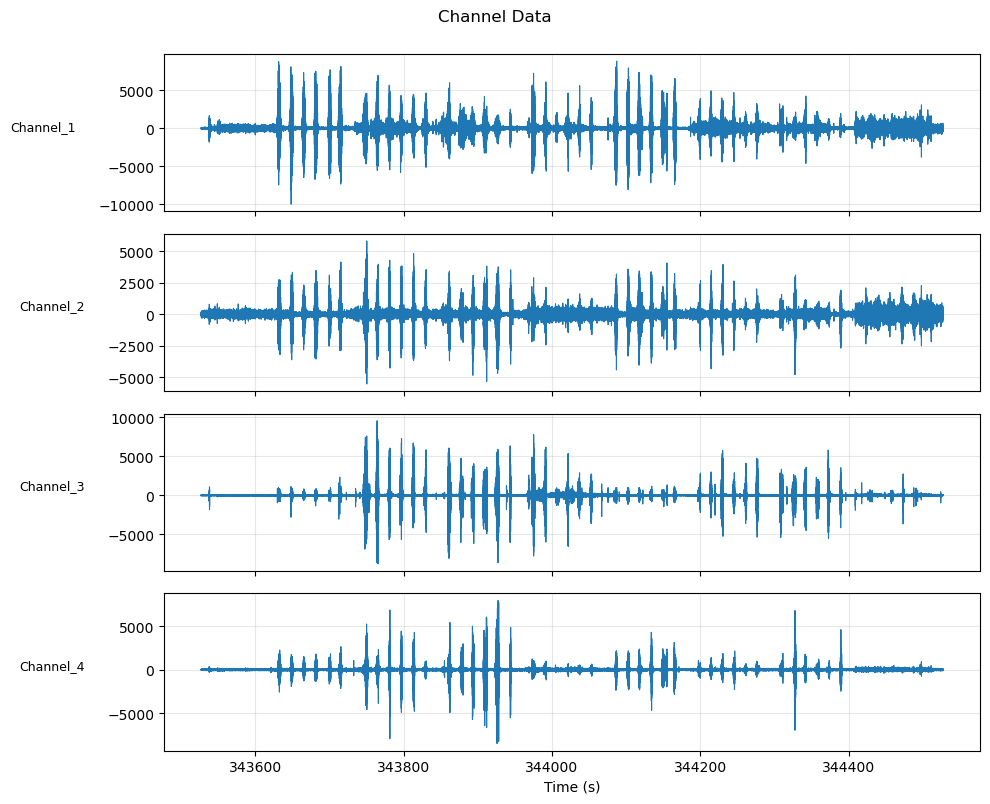

Time 0         344912.597219
1         344912.599219
2         344912.601219
3         344912.603219
4         344912.605219
              ...      
505734    345924.089888
505735    345924.091888
505736    345924.093888
505737    345924.095888
505738    345924.097888
Name: Time, Length: 505739, dtype: float64
Channels         Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  Channel_6
0          8188.0     8217.0     8179.0     8221.0     8191.0     6131.0
1          8197.0     8215.0     8162.0     8163.0     8186.0     6143.0
2          8192.0     8302.0     8153.0     8215.0     8188.0     6126.0
3          8212.0     8290.0     8149.0     8202.0     8196.0     6076.0
4          8185.0     8214.0     8173.0     8179.0     8197.0     6093.0
...           ...        ...        ...        ...        ...        ...
505734     8161.0     8071.0     8184.0     8261.0     8241.0     6078.0
505735     8164.0     8023.0     8242.0     8187.0     8192.0     6089.0
505736     8199.0     

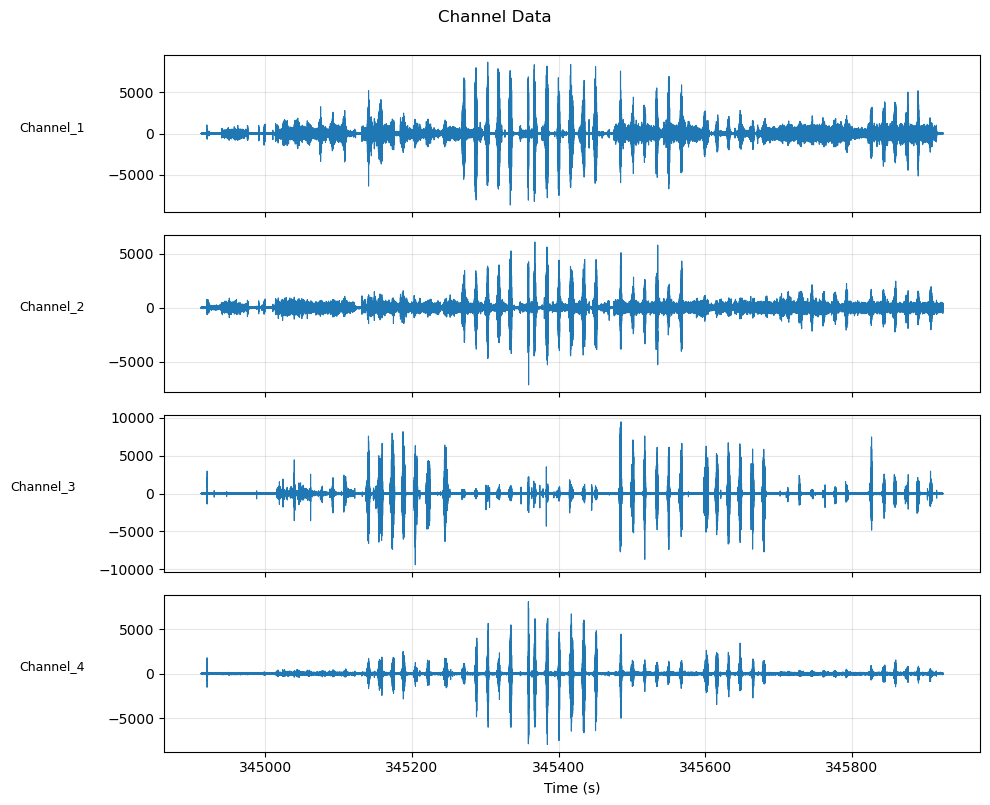

In [52]:
for file_dir, file_names in emg_files.items():
    for file in file_names:

        file_path = os.path.join(file_dir, file)
        streams, header = pyxdf.load_xdf(file_path)
        channels = streams[1]['time_series']
        timestamps = streams[1]['time_stamps']

        data_df = pd.DataFrame(data=channels, columns=['Channel_1', 'Channel_2', 'Channel_3', 'Channel_4', 'Channel_5', 'Channel_6'])
        data_df['Time'] = timestamps

        time = data_df['Time']
        channels = data_df.drop(columns='Time')

        print(f"Time {time}")
        print(f"Channels {channels}")

        filtered1_channels = notch_filter(channels, single=True)
        filtered2_channels = passband_filter(filtered1_channels, single=True)

        data_df = pd.concat([time, filtered2_channels], axis=1)

        plot_stacked_channels(data_df.drop(columns=["Channel_5", "Channel_6"]))
        

In [60]:
params = {
    'sub-P008_ses-S001_task-Default_run-001_emg_kraken.xdf': {
        'signal_t': [336120, 336200],
        'noise_t': [336020, 336100],
    },
    'sub-P008_ses-S002_task-Default_run-001_emg_kraken.xdf': {
        'signal_t': [337800, 337880],
        'noise_t': [337700, 337780],
    },
    'sub-P008_ses-S003_task-Default_run-001_emg_kraken.xdf': {
        'signal_t': [339100, 339180],
        'noise_t': [339000, 339080],
    },
    'sub-P009_ses-S001_task-Default_run-001_emg_kraken.xdf': {
        'signal_t': [342450, 342530],
        'noise_t': [342350, 342430],
    },
    'sub-P009_ses-S002_task-Default_run-001_emg_kraken.xdf': {
        'signal_t': [343650, 343730],
        'noise_t': [343550, 343630],
    },
    'sub-P009_ses-S003_task-Default_run-001_emg_kraken.xdf': {
        'signal_t': [345050, 345130],
        'noise_t': [344950, 345030],
    },
}

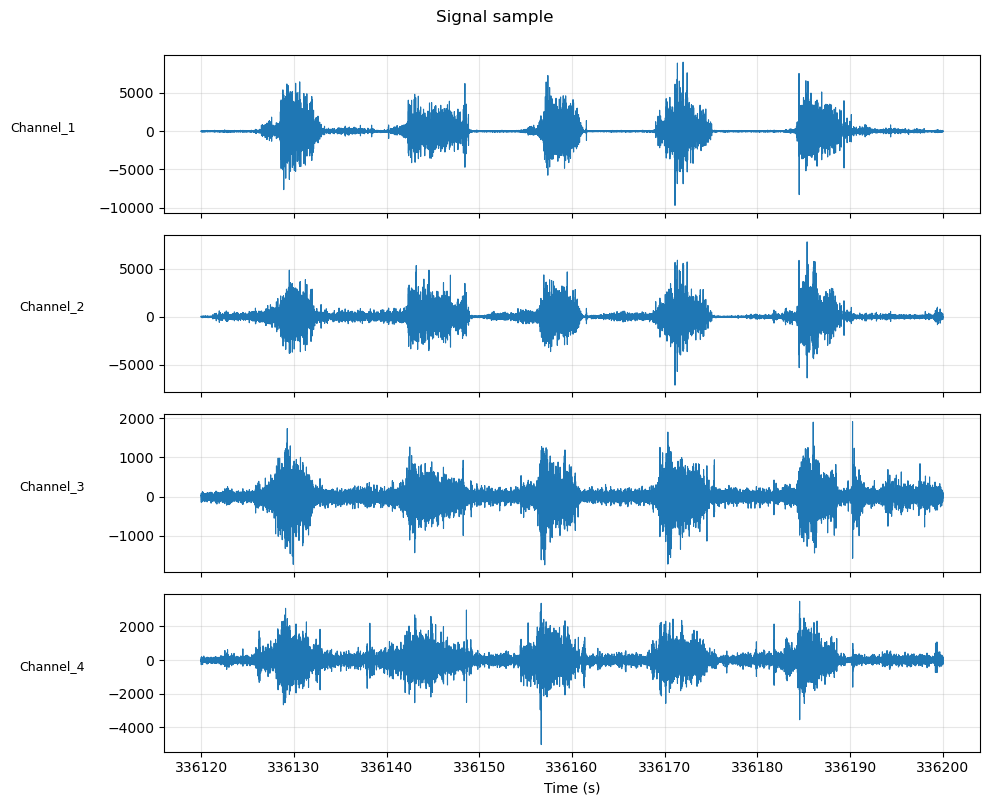

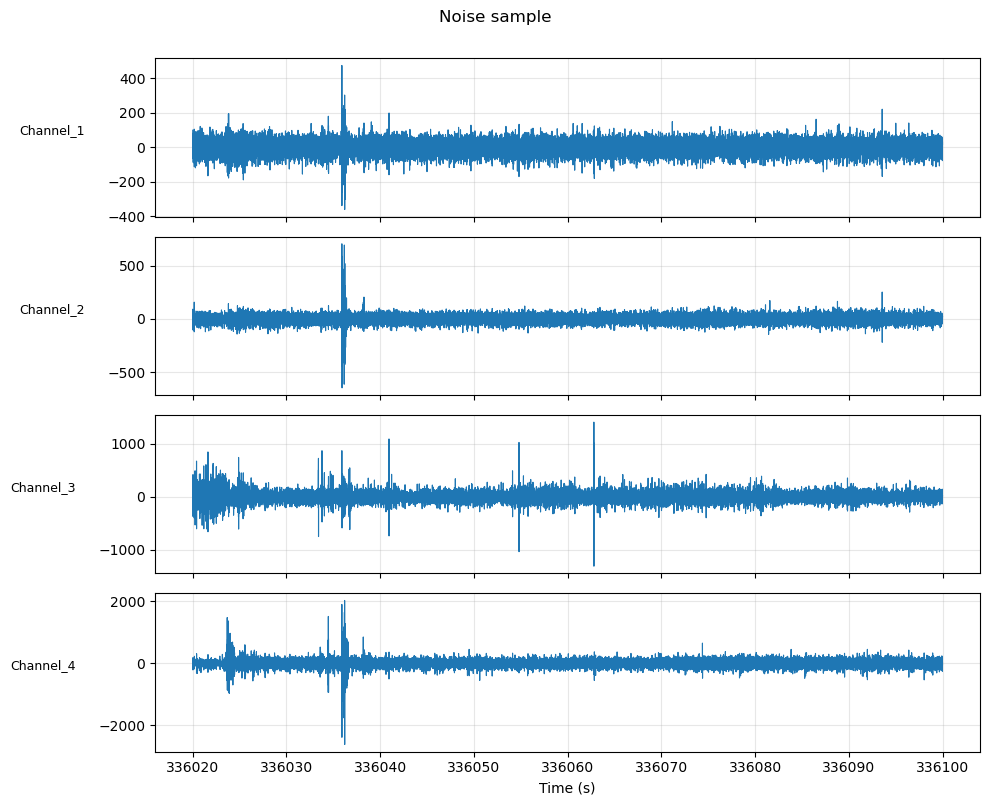

SNR for channel Channel_1: 26.240580331279702dB
SNR for channel Channel_2: 23.92825244694201dB
SNR for channel Channel_3: 7.734356161308526dB
SNR for channel Channel_4: 10.207417611708994dB
Mean SNR for sub-P008_ses-S001_task-Default_run-001_emg_kraken.xdf: 17.027651637809807


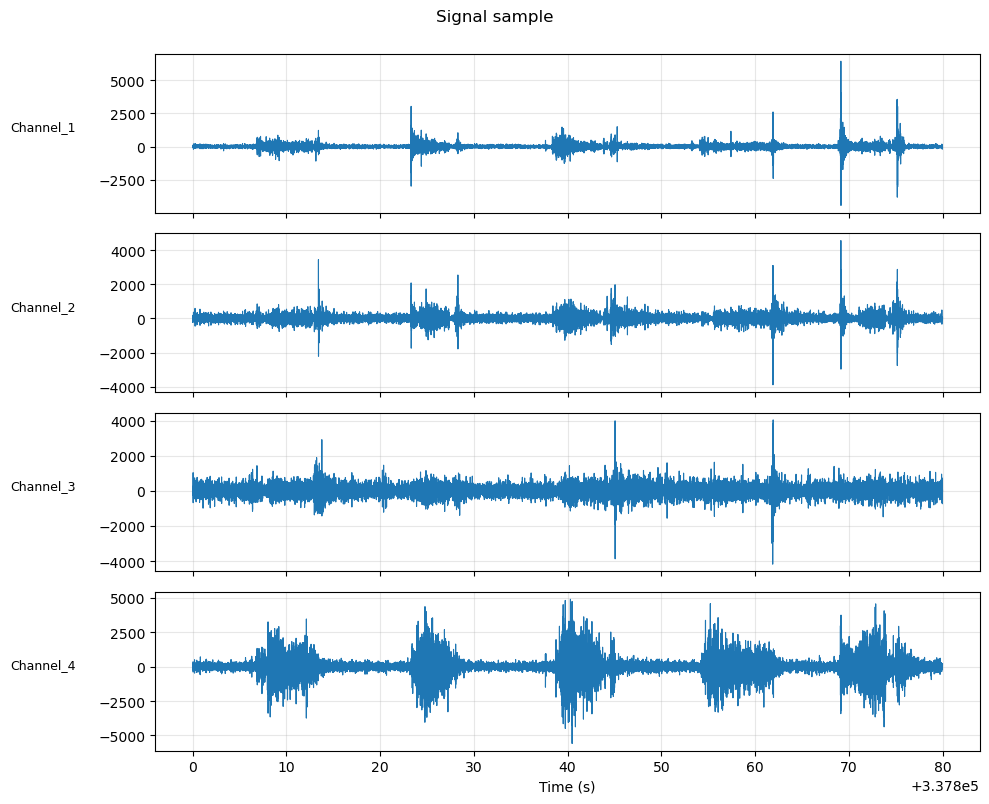

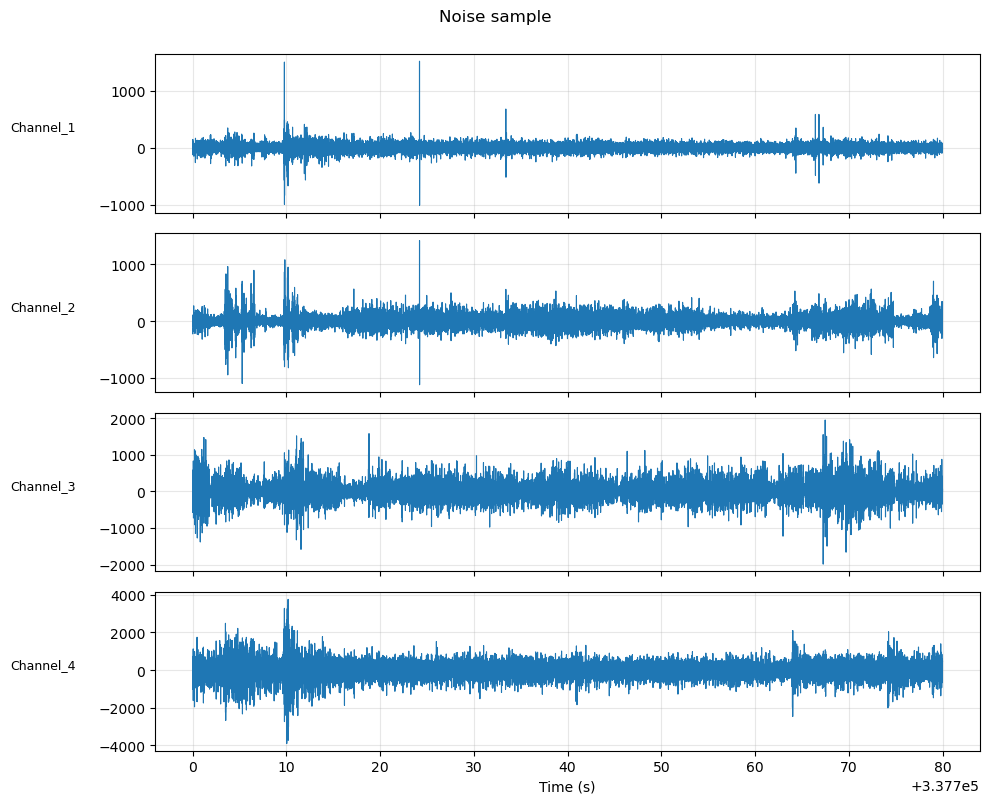

SNR for channel Channel_1: 8.99321881359249dB
SNR for channel Channel_2: 7.100028367795947dB
SNR for channel Channel_3: 2.9864745241231256dB
SNR for channel Channel_4: 3.5648908591089756dB
Mean SNR for sub-P008_ses-S002_task-Default_run-001_emg_kraken.xdf: 5.6611531411551335


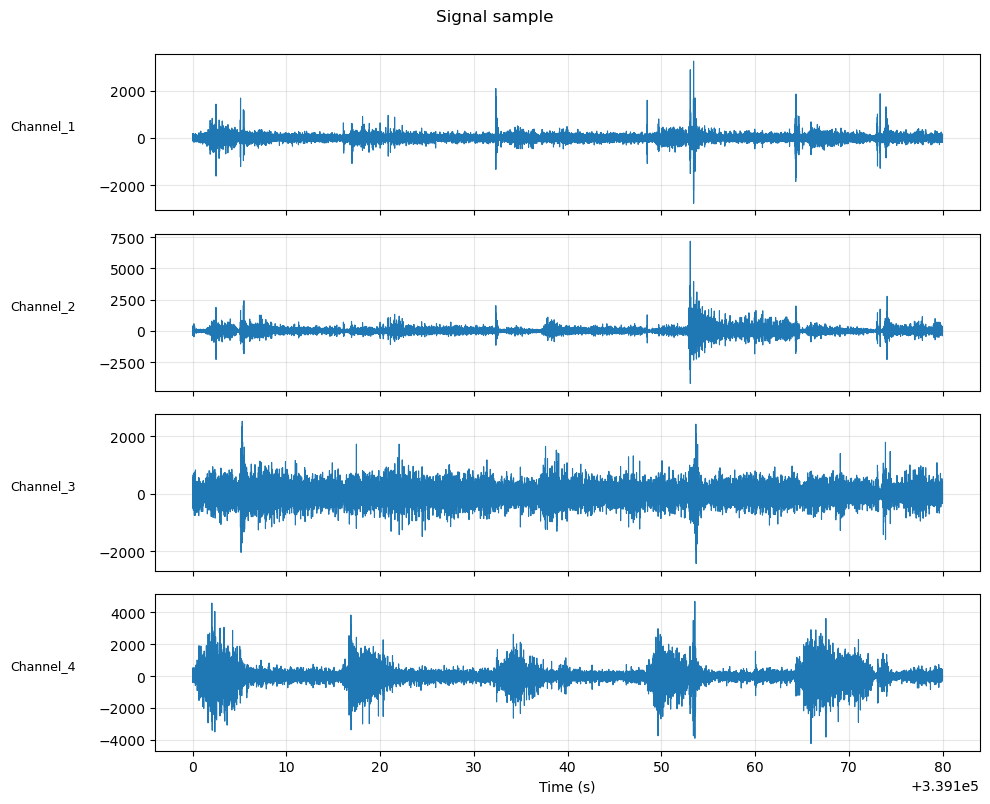

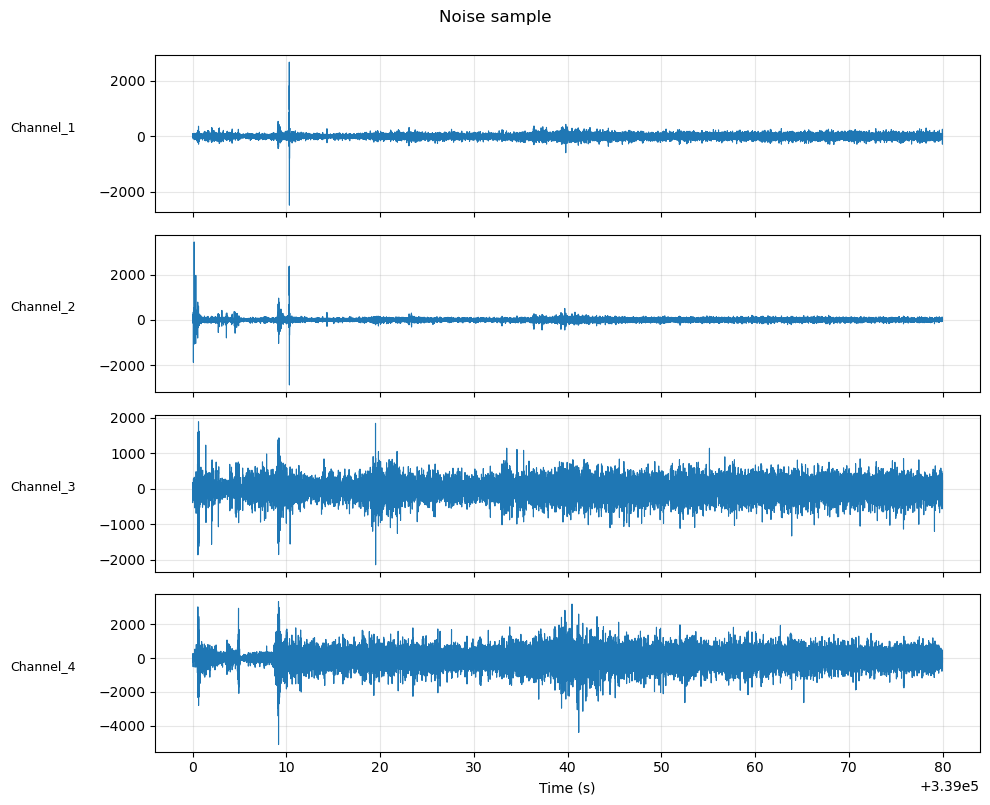

SNR for channel Channel_1: 4.99930999316774dB
SNR for channel Channel_2: 8.57631955634409dB
SNR for channel Channel_3: 2.0327983812627664dB
SNR for channel Channel_4: -0.23713972445171078dB
Mean SNR for sub-P008_ses-S003_task-Default_run-001_emg_kraken.xdf: 3.842822051580722


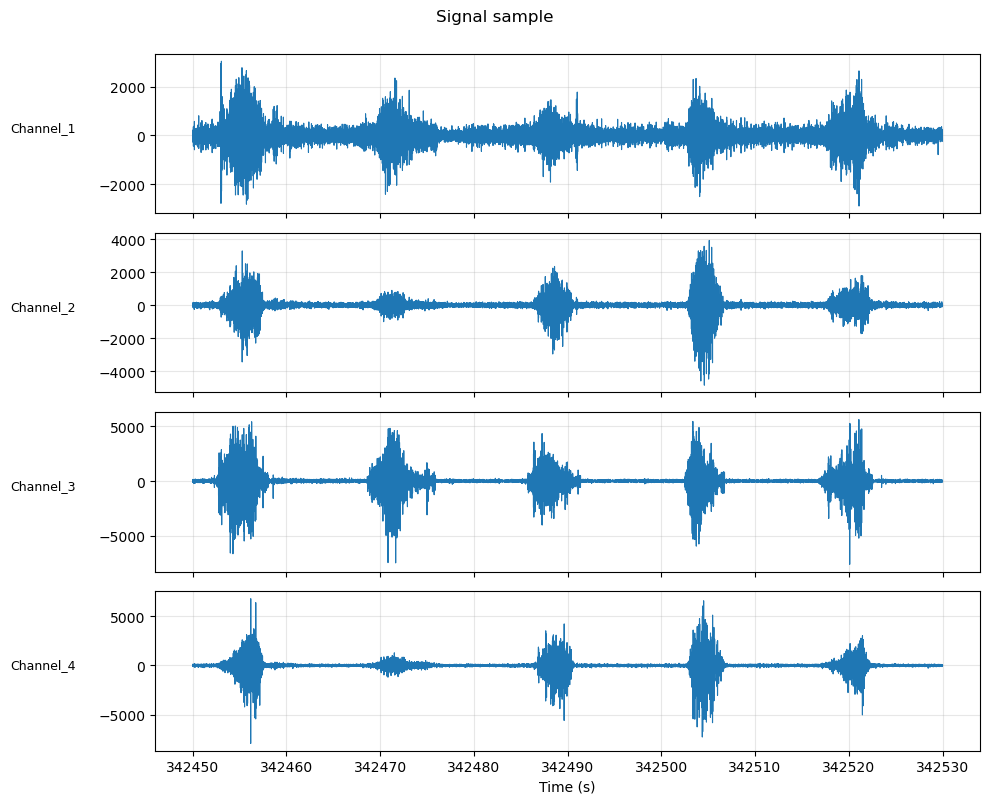

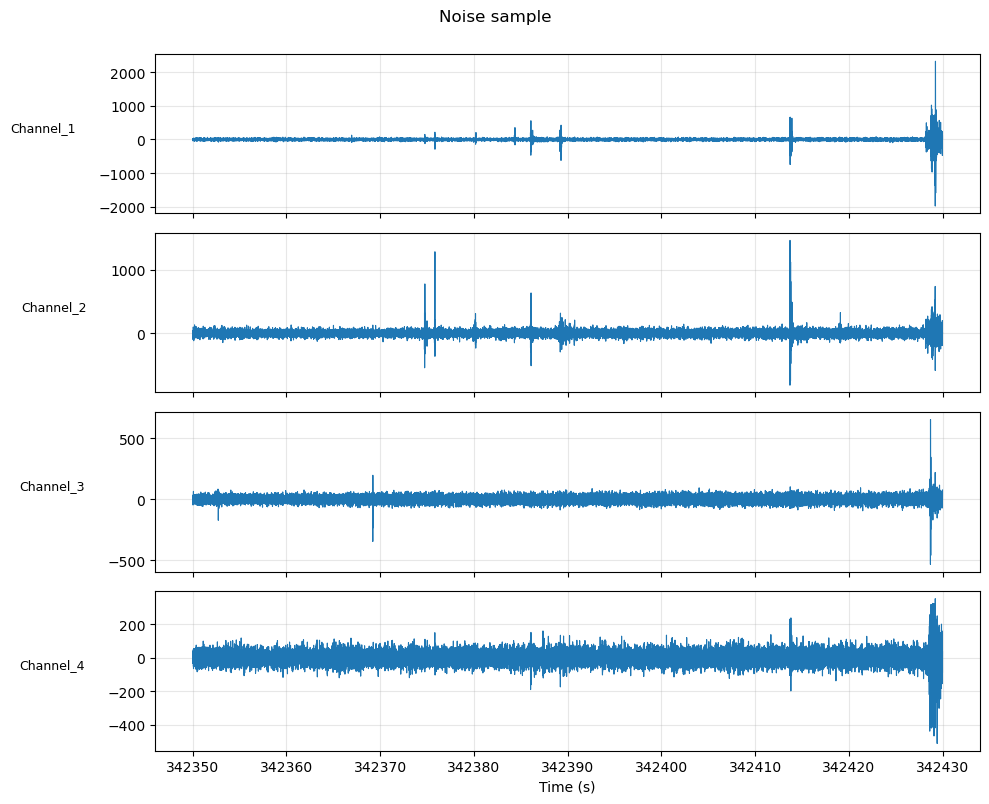

SNR for channel Channel_1: 14.501290731623978dB
SNR for channel Channel_2: 17.268096610052773dB
SNR for channel Channel_3: 27.580308630974987dB
SNR for channel Channel_4: 22.739811383844692dB
Mean SNR for sub-P009_ses-S001_task-Default_run-001_emg_kraken.xdf: 20.522376839124107


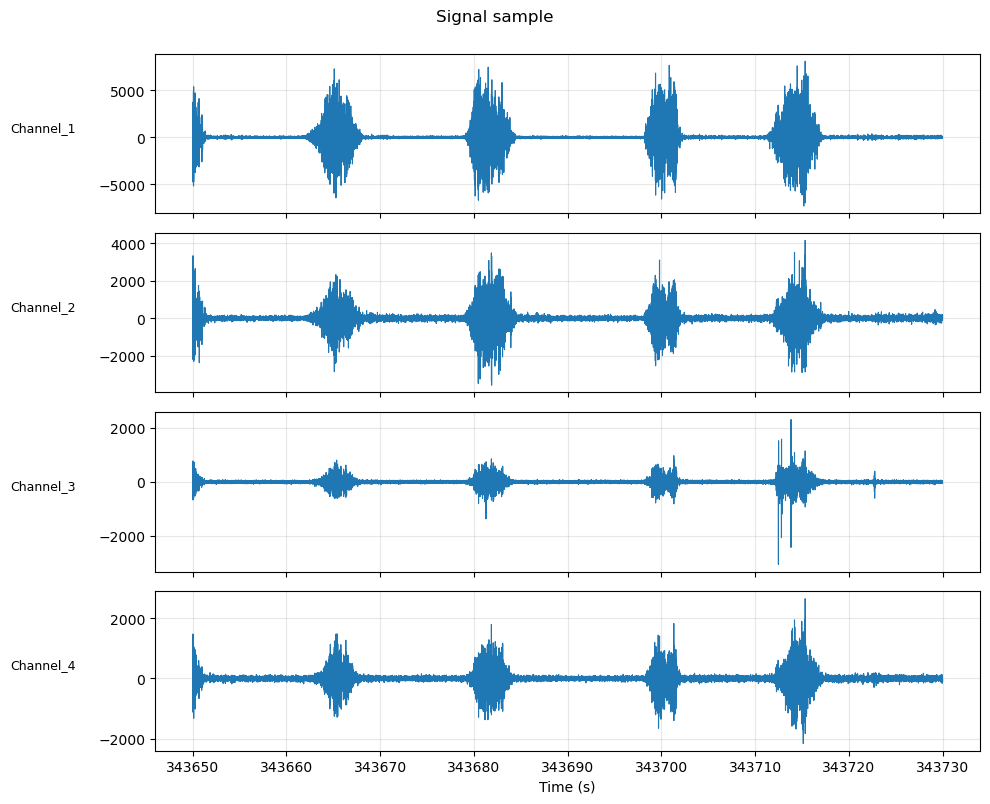

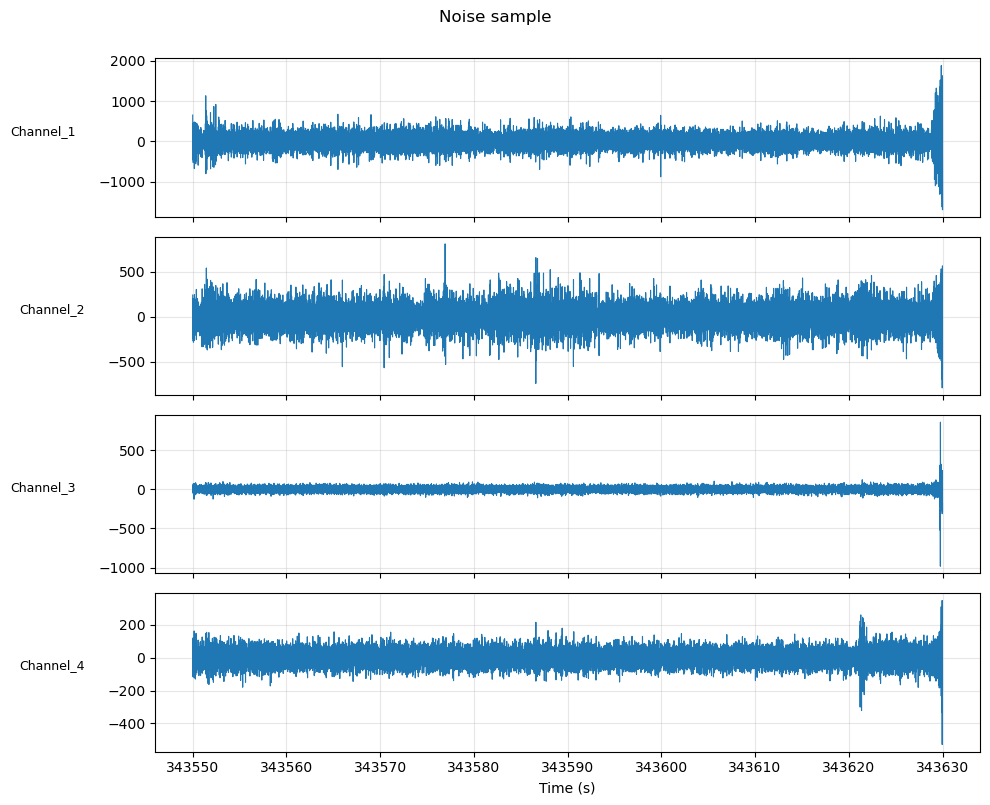

SNR for channel Channel_1: 14.898168736005974dB
SNR for channel Channel_2: 10.050944894977007dB
SNR for channel Channel_3: 11.402945835358114dB
SNR for channel Channel_4: 12.82357757912921dB
Mean SNR for sub-P009_ses-S002_task-Default_run-001_emg_kraken.xdf: 12.293909261367578


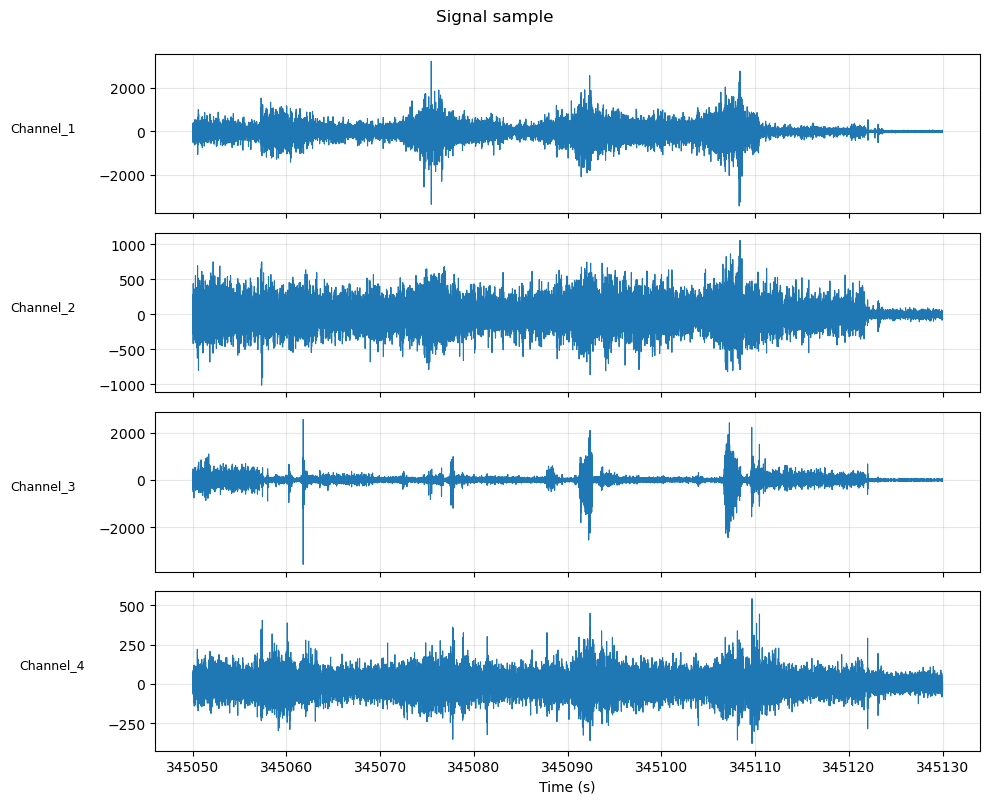

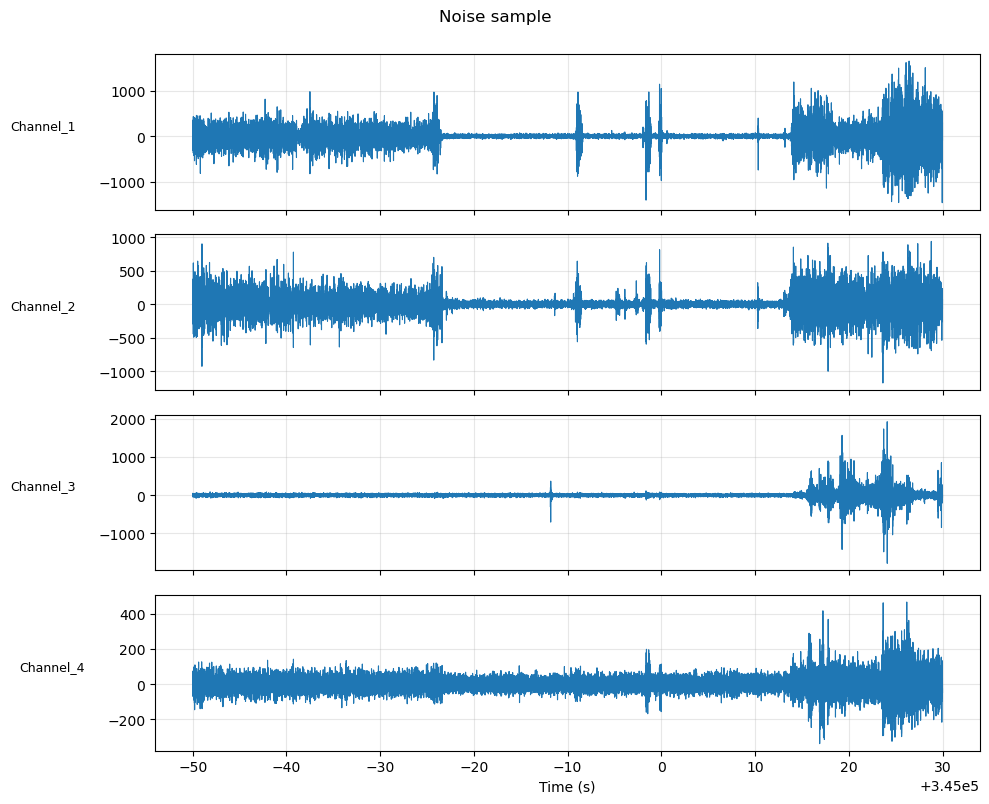

SNR for channel Channel_1: 4.699122542386554dB
SNR for channel Channel_2: 2.0286142458108354dB
SNR for channel Channel_3: 5.553570414461909dB
SNR for channel Channel_4: 3.3455361348194286dB
Mean SNR for sub-P009_ses-S003_task-Default_run-001_emg_kraken.xdf: 3.906710834369682


In [61]:
all_snr = []

for file_dir, file_names in emg_files.items():
    for file in file_names:

        file_path = os.path.join(file_dir, file)
        streams, header = pyxdf.load_xdf(file_path)
        channels = streams[1]['time_series']
        timestamps = streams[1]['time_stamps']

        data_df = pd.DataFrame(data=channels, columns=['Channel_1', 'Channel_2', 'Channel_3', 'Channel_4', 'Channel_5', 'Channel_6'])
        data_df['Time'] = timestamps

        time = data_df['Time']
        channels = data_df.drop(columns='Time')

        # print(f"Time {time}")
        # print(f"Channels {channels}")

        filtered1_channels = notch_filter(channels, single=True)
        filtered2_channels = passband_filter(filtered1_channels, single=True)

        data_df = pd.concat([time, filtered2_channels], axis=1)

        p = params.get(file)
        if p is None:
            print(f"Skipping {file}: no params entry")
            continue

        sig_t0, sig_t1 = p['signal_t']
        noi_t0, noi_t1 = p['noise_t']

        # Use & and parentheses for pandas boolean indexing; use .loc to be explicit
        signal = data_df.loc[(data_df['Time'] >= sig_t0) & (data_df['Time'] < sig_t1)].copy().drop(columns=["Channel_5", "Channel_6"])
        noise  = data_df.loc[(data_df['Time'] >= noi_t0) & (data_df['Time'] < noi_t1)].copy().drop(columns=["Channel_5", "Channel_6"])

        plot_stacked_channels(signal, title='Signal sample')
        plot_stacked_channels(noise, title='Noise sample')

        snr_list = []
        for col_name, data in signal.items():
            if "Channel" in col_name:    
                s = signal[col_name].values
                n = noise[col_name].values

                snr = compute_snr(s, n)
                print(f"SNR for channel {col_name}: {snr}dB")
                snr_list.append(snr)

        snr_mean = np.mean(snr_list)
        print(f"Mean SNR for {file}: {snr_mean}")
        all_snr.append(snr_mean)

In [62]:
snr_mean = np.mean(all_snr)
snr_std = np.std(all_snr)

print(f"Mean SNR: {snr_mean}, std {snr_std}")

Mean SNR: 10.542437294234505, std 6.550693315549024
